In [46]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = '/root/workspace/vllm/examples/logs/1gpu_bs512_prompts300'
BASELINE_DATA_PATH = '/root/workspace/vllm-org/vllm/examples/logs/org_recompute_chunked_prefill'
linestyles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '*', 'p', 'h']
hatches = ['////', '\\\\\\', '||||', '----', '++++', 'xx', 'oo', 'OO', '.', '**']

In [47]:
def get_res(model_name, gpu_utilization, req_rate, total_req, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot,  mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []
    for store_cache_layer in store_cache_layers:
        filename = f'{DATA_PATH}/test_{model_name}_client_{gpu_utilization}_{req_rate}_{total_req}_{baseline_policy}_{store_cache_layer}.log'
        with open(filename, 'r') as f:
            lines = f.readlines()
            output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft_, p99_ttft_, mean_itl_, p99_itl_ = [], [], [], [], [], [], [], []
            for line in lines:
                if 'Output token throughput' in line:
                    output_tokens_tgt.append(float(line.split()[-1]))
                if 'Request throughput' in line:
                    reqs_tgt.append(float(line.split()[-1]))
                if 'Mean TPOT' in line:
                    mean_tpot_.append(float(line.split()[-1]))
                if 'P99 TPOT' in line:
                    p99_tpot_.append(float(line.split()[-1]))
                if 'Mean TTFT' in line:
                    mean_ttft_.append(float(line.split()[-1]))
                if 'P99 TTFT' in line:
                    p99_ttft_.append(float(line.split()[-1]))    
                if 'Mean ITL' in line:
                    mean_itl_.append(float(line.split()[-1]))
                if 'P99 ITL' in line:
                    p99_itl_.append(float(line.split()[-1]))    

        output_tokens.append(np.mean(output_tokens_tgt))
        reqs.append(np.mean(reqs_tgt))
        mean_tpot.append(np.mean(mean_tpot_))
        p99_tpot.append(np.mean(p99_tpot_))
        mean_ttft.append(np.mean(mean_ttft_))
        p99_ttft.append(np.mean(p99_ttft_))
        mean_itl.append(np.mean(mean_itl_))
        p99_itl.append(np.mean(p99_itl_))

    return output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl 

In [48]:
def get_baseline_res(model_name, gpu_utilization, req_rate, total_req, baseline_policy):   
    filename = f'{BASELINE_DATA_PATH}/{model_name}_client_{gpu_utilization}_{req_rate}_{total_req}_{baseline_policy}_bs256_chunkedsize512.log'
    with open(filename, 'r') as f:
        lines = f.readlines()
        output_tokens_tgt, reqs_tgt, mean_tpot_, p99_tpot_, mean_ttft, p99_ttft, mean_itl, p99_itl = [], [], [], [], [], [], [], []
        for line in lines:
            if 'Output token throughput' in line:
                output_tokens_tgt.append(float(line.split()[-1]))
            if 'Request throughput' in line:
                reqs_tgt.append(float(line.split()[-1]))
            if 'Mean TPOT' in line:
                mean_tpot_.append(float(line.split()[-1]))
            if 'P99 TPOT' in line:
                p99_tpot_.append(float(line.split()[-1]))
            if 'Mean TTFT' in line:
                mean_ttft.append(float(line.split()[-1]))  
            if 'P99 TTFT' in line:
                p99_ttft.append(float(line.split()[-1]))      
            if 'Mean ITL' in line:
                mean_itl.append(float(line.split()[-1]))
            if 'P99 ITL' in line:
                p99_itl.append(float(line.split()[-1]))        
        
    return np.mean(output_tokens_tgt), np.mean(reqs_tgt), np.mean(mean_tpot_), np.mean(p99_tpot_), np.mean(mean_ttft), np.mean(p99_ttft), np.mean(mean_itl), np.mean(p99_itl)         

In [49]:
# plot throughput
def plot_throughput(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy):
    output_tokens, reqs, mean_tpot, p99_tpot, mean_ttft, p99_ttft, mean_itl, p99_itl = get_res(model_name, gpu_utilization, req_rate, total_reqs, store_cache_layers, baseline_policy)
    baseline_output_tokens, baseline_reqs, baseline_mean_tpot, baseline_p99_tpot, baseline_mean_ttft, baseline_p99_ttft, baseline_mean_itl, baseline_p99_itl = get_baseline_res(model_name, gpu_utilization, req_rate, total_reqs, baseline_policy)
    # 计算增长百分比
    output_tokens_imp = [(output_tokens[i]-baseline_output_tokens) / baseline_output_tokens * 100 for i in range(len(output_tokens))]
    reqs_imp = [(reqs[i]-baseline_reqs) / baseline_reqs * 100 for i in range(len(reqs))]
    mean_tpot_imp = [(baseline_mean_tpot-mean_tpot[i]) / baseline_mean_tpot *100 for i in range(len(mean_tpot))]
    p99_tpot_imp = [(baseline_p99_tpot-p99_tpot[i]) / baseline_p99_tpot *100 for i in range(len(p99_tpot))]
    mean_ttft_imp = [(baseline_mean_ttft-mean_ttft[i]) / baseline_mean_ttft *100 for i in range(len(mean_ttft))]
    p99_ttft_imp = [(baseline_p99_ttft-p99_ttft[i]) / baseline_p99_ttft *100 for i in range(len(p99_ttft))]
    mean_itl_imp = [(baseline_mean_itl-mean_itl[i]) / baseline_mean_itl *100 for i in range(len(mean_itl))]
    p99_itl_imp = [(baseline_p99_itl-p99_itl[i]) / baseline_p99_itl *100 for i in range(len(p99_itl))]

    return output_tokens_imp, reqs_imp, mean_tpot_imp, p99_tpot_imp, mean_ttft_imp, p99_ttft_imp, mean_itl_imp, p99_itl_imp
    

In [50]:
def plot_big_fig(baseline_policy, req_rates, store_cache_layers, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(6, 2.3), dpi=120)
    axes = [fig.add_subplot(1, 2, i+1) for i in range(2)]
    for i, ax in enumerate(axes):
        ax.plot(store_cache_layers, mean_output_tokens_imps[i], label='Token Tgt', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
        ax.plot(store_cache_layers, mean_reqs_imps[i], label='Req Tgt', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_tpot_imps[i], label='P99 TPOT', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_ttft_imps[i], label='P99 TTFT', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5)
        ax.plot(store_cache_layers, mean_p99_itl_imps[i], label='P99 ITL', linestyle=linestyles[3], marker=markers[7], color=plt.cm.Dark2(7/6), markersize=5)
        ax.set_xlabel('Cache layers (%)')
        if i == 0 : ax.set_ylabel('Improvement (%)')
        elif i==1:
            # parse the legend label and remove the legend of the ax
            handles, labels = ax.get_legend_handles_labels()
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(linestyle='-.', alpha=0.3)
        ax.set_xticks(store_cache_layers)
        ax.set_xticklabels([f'{int(x*100)}' for x in ax.get_xticks()])
        ax.set_ylim(-300, 200)
        ax.yaxis.set_major_locator(plt.MultipleLocator(100))
    fig.legend(handles, labels,loc=(0.1,0.86), ncol=8, frameon=False, columnspacing=0.5, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0., w_pad=0.1, h_pad=0.1, rect=[0, 0, 1, 0.9])
    plt.savefig(f'./pdf/{baseline_policy}_1gpu.pdf', bbox_inches='tight')
    plt.show()

In [51]:
def plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps):
    print(f'mean_output_tokens_imps: {mean_output_tokens_imps}')
    fig = plt.figure(figsize=(3, 2.3), dpi=120)
    ax = fig.add_subplot(111)
    ax.plot(req_rates, mean_output_tokens_imps, label='Token Tgt', linestyle=linestyles[0], marker=markers[0], color=plt.cm.Dark2(0/6), markersize=5)
    ax.plot(req_rates, mean_reqs_imps, label='Req Tgt', linestyle=linestyles[1], marker=markers[1], color=plt.cm.Dark2(1/6), markersize=5)
    ax.plot(req_rates, mean_p99_tpot_imps, label='P99 TPOT', linestyle=linestyles[3], marker=markers[3], color=plt.cm.Dark2(3/6), markersize=5)
    ax.plot(req_rates, mean_p99_ttft_imps, label='P99 TTFT', linestyle=linestyles[1], marker=markers[5], color=plt.cm.Dark2(5/6), markersize=5)
    ax.plot(req_rates, mean_p99_itl_imps, label='P99 ITL', linestyle=linestyles[1], marker=markers[7], color=plt.cm.Dark2(7/6), markersize=5, markerfacecolor='none')
    ax.set_xlabel('Req rate (reqs/s)')
    ax.set_ylabel('Improvement (%)')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.grid(linestyle='-.', alpha=0.3)
    ax.xaxis.set_major_locator(plt.MultipleLocator(50))
    ax.set_ylim(min(min(mean_output_tokens_imps), min(mean_reqs_imps), min(mean_mean_tpot_imps), min(mean_p99_tpot_imps), min(mean_mean_itl_imps), min(mean_p99_itl_imps))*1.4, max(max(mean_output_tokens_imps), max(mean_reqs_imps), max(mean_mean_tpot_imps), max(mean_p99_tpot_imps), max(mean_mean_itl_imps), max(mean_p99_itl_imps))*1.4)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc=(0.1,0.82), ncol=3, frameon=False, columnspacing=0.5, labelspacing=0.2, handlelength=1.5, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0., w_pad=0.1, h_pad=0.1, rect=[0, 0, 1, 0.9])
    plt.show()

In [54]:
def plot_all_figs(model_name, gpu_utilization):
    model_name = model_name.replace('/', '_')
    req_rates = [50, 100, 150, 200, 250, 300]
    total_reqs = [300, 300, 300, 300, 300, 300]
    store_cache_layers = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    baseline_policies = ['swap']
    for baseline_policy in baseline_policies:
        print(f'baseline_policy---------------------->: {baseline_policy}')
        mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps = [], [], [], [], [], [], [], []
        output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_ttft_imps_all, p99_ttft_imps_all, mean_itl_imps_all, p99_itl_imps_all = [], [], [], [], [], [], [], []
        for i in range(len(req_rates)):
            req_rate = req_rates[i]
            total_req = total_reqs[i]
            output_tokens_imps, reqs_imps, mean_tpot_imps, p99_tpot_imps, mean_ttft_imps, p99_ttft_imps, mean_itl_imps, p99_itl_imps = plot_throughput(model_name, gpu_utilization, req_rate, total_req, store_cache_layers, baseline_policy)
            mean_output_tokens_imps.append(np.mean(output_tokens_imps))
            mean_reqs_imps.append(np.mean(reqs_imps))
            mean_mean_tpot_imps.append(np.mean(mean_tpot_imps))
            mean_p99_tpot_imps.append(np.mean(p99_tpot_imps))
            mean_mean_ttft_imps.append(np.mean(mean_ttft_imps))
            mean_p99_ttft_imps.append(np.mean(p99_ttft_imps))
            mean_mean_itl_imps.append(np.mean(mean_itl_imps))
            mean_p99_itl_imps.append(np.mean(p99_itl_imps))

            output_tokens_imps_all.append(output_tokens_imps)
            reqs_imps_all.append(reqs_imps)
            mean_tpot_imps_all.append(mean_tpot_imps)
            p99_tpot_imps_all.append(p99_tpot_imps)
            mean_ttft_imps_all.append(mean_ttft_imps)
            p99_ttft_imps_all.append(p99_ttft_imps)
            mean_itl_imps_all.append(mean_itl_imps)
            p99_itl_imps_all.append(p99_itl_imps)

        plot_big_fig(baseline_policy, req_rates, store_cache_layers, output_tokens_imps_all, reqs_imps_all, mean_tpot_imps_all, p99_tpot_imps_all, mean_ttft_imps_all, p99_ttft_imps_all, mean_itl_imps_all, p99_itl_imps_all)
        print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_ttft_imps: {np.mean(mean_mean_ttft_imps)}, mean_p99_ttft_imps: {np.mean(mean_p99_ttft_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')
        plot_sub_fig(baseline_policy, req_rates, mean_output_tokens_imps, mean_reqs_imps, mean_mean_tpot_imps, mean_p99_tpot_imps, mean_mean_ttft_imps, mean_p99_ttft_imps, mean_mean_itl_imps, mean_p99_itl_imps)

        print(f'mean_output_tokens_imps: {np.mean(mean_output_tokens_imps)}, mean_reqs_imps: {np.mean(mean_reqs_imps)}, mean_mean_tpot_imps: {np.mean(mean_mean_tpot_imps)}, mean_p99_tpot_imps: {np.mean(mean_p99_tpot_imps)}, mean_mean_ttft_imps: {np.mean(mean_mean_ttft_imps)}, mean_p99_ttft_imps: {np.mean(mean_p99_ttft_imps)}, mean_mean_itl_imps: {np.mean(mean_mean_itl_imps)}, mean_p99_itl_imps: {np.mean(mean_p99_itl_imps)}')

        print(f'mean_p99_tpot_imps: {mean_p99_tpot_imps}')
        base_imps = []
        base_imps.append(np.mean(mean_output_tokens_imps))
        base_imps.append(np.mean(mean_reqs_imps))
        base_imps.append(np.mean(mean_mean_tpot_imps))
        base_imps.append(np.mean(mean_p99_tpot_imps))
        base_imps.append(np.mean(mean_mean_ttft_imps))
        base_imps.append(np.mean(mean_p99_ttft_imps))
        base_imps.append(np.mean(mean_mean_itl_imps))
        base_imps.append(np.mean(mean_p99_itl_imps))


baseline_policy---------------------->: swap
mean_output_tokens_imps: [[131.7491657258807, 126.25862249033935, 126.26856912663563, 105.6143788574299, 76.14995548880259, 57.330919616258804, 44.68874488369897, 31.768064334843572, 20.309539321539948], [144.50273191561033, 146.0730261104754, 104.83175065511486, 92.9232735432673, 72.73236143515973, 57.49010516512858, 43.71659409628827, 30.94371213584778, 24.120115121883565], [141.96960718535897, 147.33952682021422, 124.30984411806479, 97.05131909516979, 76.49478679484606, 55.874589236653584, 40.856934370913805, 29.35556067054209, 25.31771412340286], [162.05005293494884, 142.18964435556603, 109.13470964200293, 88.77681057130535, 68.40665804023057, 34.72189546327885, 46.25730306238482, 29.256852135042944, 17.424910794808465], [164.4403398596232, 144.62750892747198, 114.6459795591676, 93.11661125477157, 73.59931042975002, 51.80396502893731, 45.730821327422724, 36.90678487870951, 25.629848540820095], [144.9441349016833, 145.16769356249324, 120.

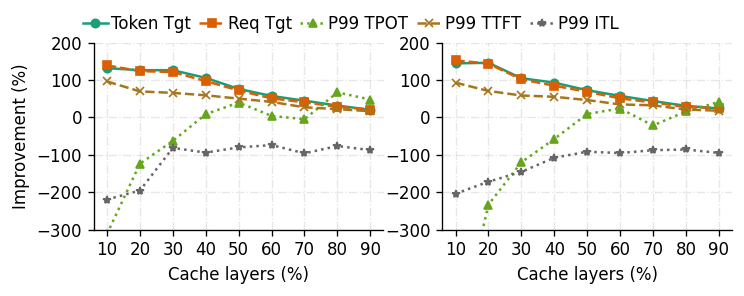

mean_output_tokens_imps: 81.55112523306539, mean_reqs_imps: 78.74060304567318, mean_mean_tpot_imps: -46.014337523286294, mean_p99_tpot_imps: -79.72480817080454, mean_mean_ttft_imps: 53.369295682968385, mean_p99_ttft_imps: 47.74309168399426, mean_mean_itl_imps: -21.933094880541976, mean_p99_itl_imps: -101.58222515814049
mean_output_tokens_imps: [80.01532887171439, 79.7037411309751, 82.0633202683518, 77.57987077772987, 83.38901886740821, 86.55547148221301]


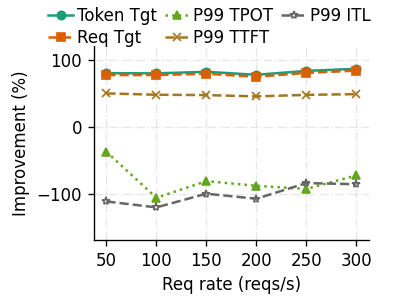

mean_output_tokens_imps: 81.55112523306539, mean_reqs_imps: 78.74060304567318, mean_mean_tpot_imps: -46.014337523286294, mean_p99_tpot_imps: -79.72480817080454, mean_mean_ttft_imps: 53.369295682968385, mean_p99_ttft_imps: 47.74309168399426, mean_mean_itl_imps: -21.933094880541976, mean_p99_itl_imps: -101.58222515814049
mean_p99_tpot_imps: [-37.268539464727276, -106.11448061281914, -81.14963701781772, -88.226287085409, -92.93580255656671, -72.6541022874873]


In [57]:
model_name = 'meta-llama/Llama-2-13b-hf'
gpu_utilization = 0.4
plot_all_figs(model_name, gpu_utilization)